In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 311_Service_Requests_from_2010_to_Present.csv (1).zip to 311_Service_Requests_from_2010_to_Present.csv (1).zip


In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import zipfile
import io

zip_file_name = list(uploaded.keys())[0]
zip_content = uploaded[zip_file_name]

# Use BytesIO to handle the zip content in memory
with zipfile.ZipFile(io.BytesIO(zip_content), 'r') as z:
    # Assuming the CSV file inside the zip has the same name but without .zip
    # Or, if the zip contains multiple files, you might need to specify the exact CSV file name
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    if csv_files:
        # Read the first CSV file found in the zip archive
        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f, low_memory=False)
    else:
        raise ValueError("No CSV file found in the zip archive.")

df.head()

Saving 311_Service_Requests_from_2010_to_Present.csv (1).zip to 311_Service_Requests_from_2010_to_Present.csv (1) (1).zip


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
import numpy as np
df.drop_duplicates(inplace=True)

df['Created Date'] = pd.to_datetime(df['Created Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Fill NaN values in numeric columns with 0
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill NaN values in object (string) columns with 'Unknown'
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].fillna('Unknown')

display(df.head()) # Display the head after cleaning to confirm

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,2015-12-31 23:59:45,2016-01-01 00:55:15,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,Unknown,Unknown,Unknown,Unknown,0.0,Unknown,Unknown,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,2015-12-31 23:59:44,2016-01-01 01:26:57,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,Unknown,Unknown,Unknown,Unknown,0.0,Unknown,Unknown,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,2015-12-31 23:59:29,2016-01-01 04:51:03,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,Unknown,Unknown,Unknown,Unknown,0.0,Unknown,Unknown,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,2015-12-31 23:57:46,2016-01-01 07:43:13,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,Unknown,Unknown,Unknown,Unknown,0.0,Unknown,Unknown,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,2015-12-31 23:56:58,2016-01-01 03:24:42,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,Unknown,Unknown,Unknown,Unknown,0.0,Unknown,Unknown,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [5]:
df['Resolution_Delay'] = (
    df['Closed Date'].astype('datetime64[ns]') - df['Created Date'].astype('datetime64[ns]')
).dt.days

In [6]:
priority = ['Low','Medium','High']

df['Priority'] = np.random.choice(priority, len(df))

score = {
    'Low':1,
    'Medium':2,
    'High':3
}

df['Severity_Score'] = df['Priority'].map(score)

In [7]:
total_complaints = len(df)

resolved_complaints = (
    df['Status'] == 'Closed'
).sum()

resolution_rate = (
    resolved_complaints/total_complaints
)*100

avg_resolution_time = (
    df['Resolution_Delay'].mean()
)

print("Total Complaints:", total_complaints)
print("Resolved Complaints:", resolved_complaints)
print("Resolution Rate:", round(resolution_rate,2))
print("Average Resolution Time:", round(avg_resolution_time,2))

Total Complaints: 364558
Resolved Complaints: 362114
Resolution Rate: 99.33
Average Resolution Time: 0.01


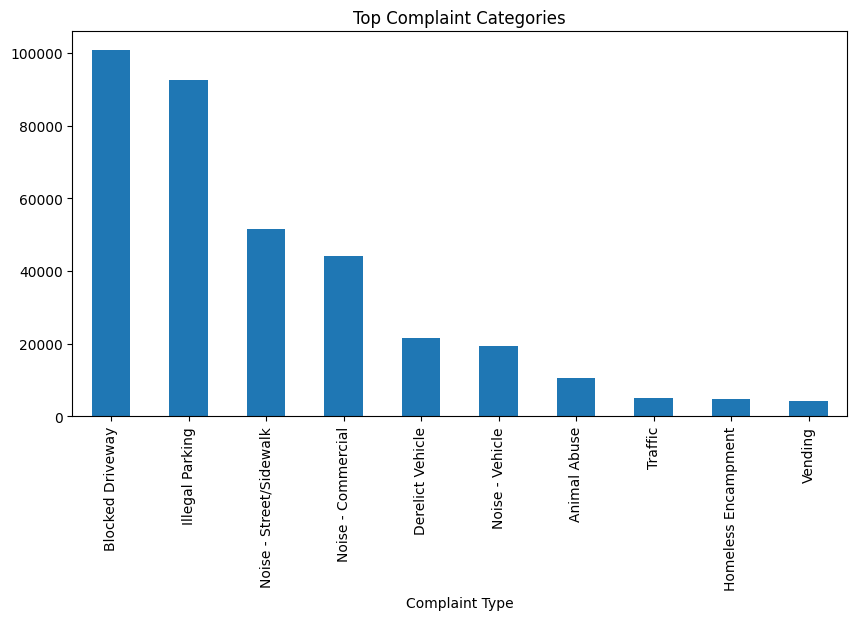

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df['Complaint Type'].value_counts().head(10).plot(kind='bar')

plt.title("Top Complaint Categories")
plt.show()

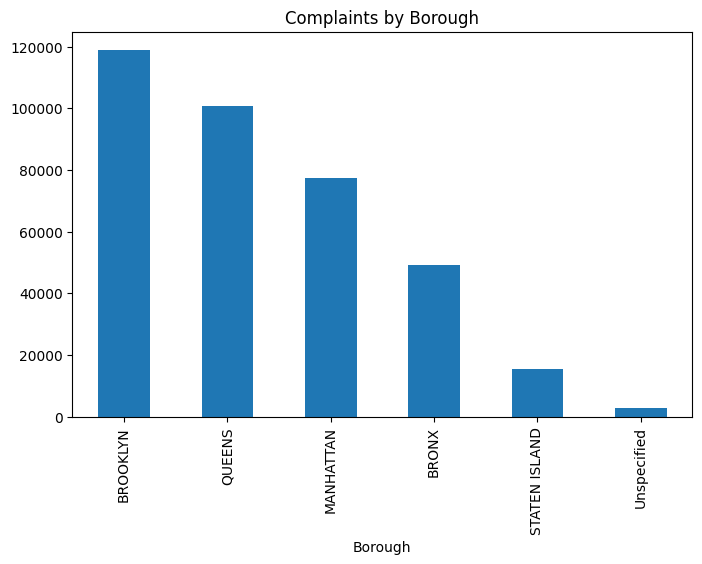

In [9]:
plt.figure(figsize=(8,5))

df['Borough'].value_counts().plot(kind='bar')

plt.title("Complaints by Borough")
plt.show()

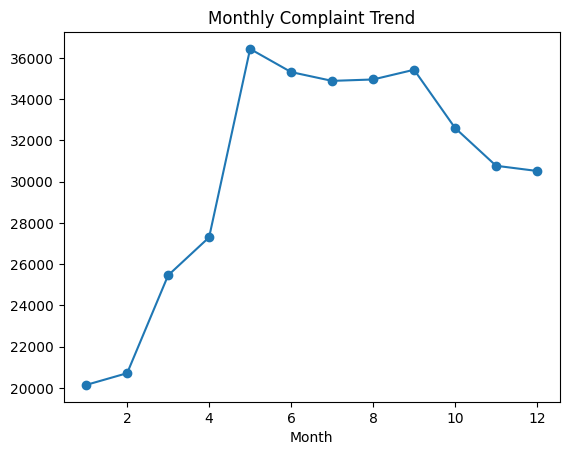

In [10]:
df['Month'] = df['Created Date'].dt.month

monthly = df.groupby('Month').size()

monthly.plot(marker='o')

plt.title("Monthly Complaint Trend")
plt.show()

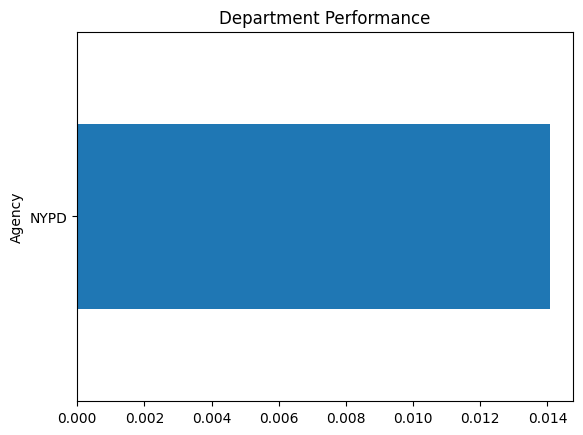

In [11]:
dept = df.groupby('Agency')['Resolution_Delay'].mean()

dept.sort_values().head(10).plot(kind='barh')

plt.title("Department Performance")
plt.show()

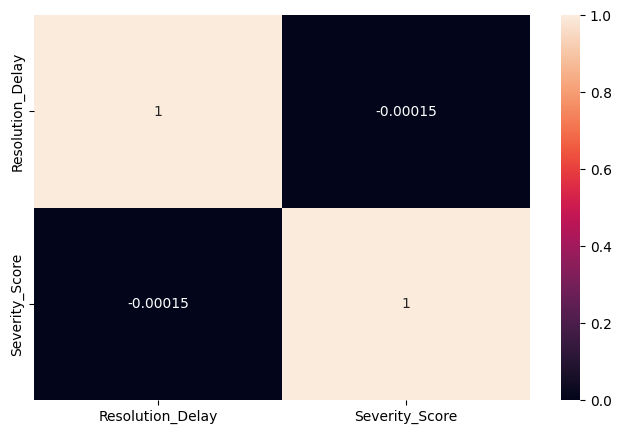

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Resolution_Delay',
        'Severity_Score']].corr(),
    annot=True
)

plt.show()

In [13]:
print("Most Frequent Complaint:")
print(df['Complaint Type'].value_counts().idxmax())

print("\nMost Problematic Area:")
print(df['Borough'].value_counts().idxmax())

print("\nSlowest Department:")
print(df.groupby('Agency')['Resolution_Delay'].mean().idxmax())

Most Frequent Complaint:
Blocked Driveway

Most Problematic Area:
BROOKLYN

Slowest Department:
NYPD
